#Week 5Machine Learning Fundamentals
Handling Imbalanced & Messy Real-World Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("creditcard.csv")

Saving creditcard.csv to creditcard.csv


#Class balance

In [3]:
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


#Visualize

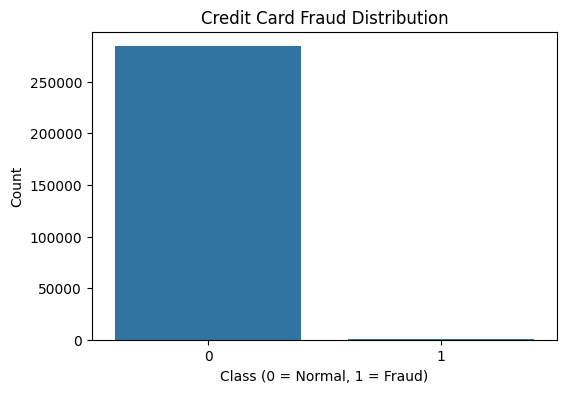

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Credit Card Fraud Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

#Train/Test Split

In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Train Original model

In [6]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#Evaluating before Smotee

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [8]:
precision_before = precision_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred)
f1_before = f1_score(y_test, y_pred)
accuracy_before = accuracy_score(y_test, y_pred)

#Apply Smote

In [9]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

#Train Again

In [10]:
balanced_model = LogisticRegression(max_iter=1000)

balanced_model.fit(
    X_train_smote,
    y_train_smote
)

balanced_pred = balanced_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#Evaluate

In [11]:
print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [12]:
precision_after = precision_score(y_test, balanced_pred)
recall_after = recall_score(y_test, balanced_pred)
f1_after = f1_score(y_test, balanced_pred)
accuracy_after = accuracy_score(y_test, balanced_pred)

#Comparison table

In [13]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Before SMOTE": [
        accuracy_before,
        precision_before,
        recall_before,
        f1_before
    ],
    "After SMOTE": [
        accuracy_after,
        precision_after,
        recall_after,
        f1_after
    ]
})

comparison

,Metric,Before SMOTE,After SMOTE
0,Accuracy,0.999245,0.988396
1,Precision,0.839506,0.119080
2,Recall,0.693878,0.897959
3,F1 Score,0.759777,0.210275


**The Credit Card Fraud dataset is highly imbalanced because fraudulent transactions make up only a very small percentage of all transactions. A model can achieve very high accuracy simply by predicting every transaction as normal, while completely failing to detect fraud. Therefore, metrics such as Precision, Recall, and F1-score provide a much better evaluation of fraud detection performance than accuracy alone**